# Plot Autocorrelation

Here we plot the autocorrelation functions derived from the mean power spectral density of multiple voltage time series pixels, for various pump strengths.

In [213]:
import os
import sys

import matplotlib.pyplot as plt
%matplotlib widget
import numpy as np
from tqdm import tqdm
import matplotlib.cm as cm
import matplotlib.colors as mcolors

## Assign arrays for each autocorrelation file

In [214]:

pump_list = np.round(np.arange(0.13, 0.29, 0.01), 3)
autocorr_list = np.zeros((len(pump_list), 401))

for p_idx, p in enumerate(pump_list):
    autocorr_list[p_idx] = np.loadtxt(
        fname=f'Time series data/autocorr_shift_rotating_frame-pump={p}',
        dtype=complex
    )

/tmp/ipykernel_40535/3261470818.py:5: ComplexWarning: Casting complex values to real discards the imaginary part
  autocorr_list[p_idx] = np.loadtxt(


## Time array

In [215]:
DF = 50e3
bw=200
n_samples_RW=401

t_arr = 1e6 * np.arange( - n_samples_RW // 2, n_samples_RW // 2, 1) /(DF * 2 * bw)

## Plot all autocorrelation graphs

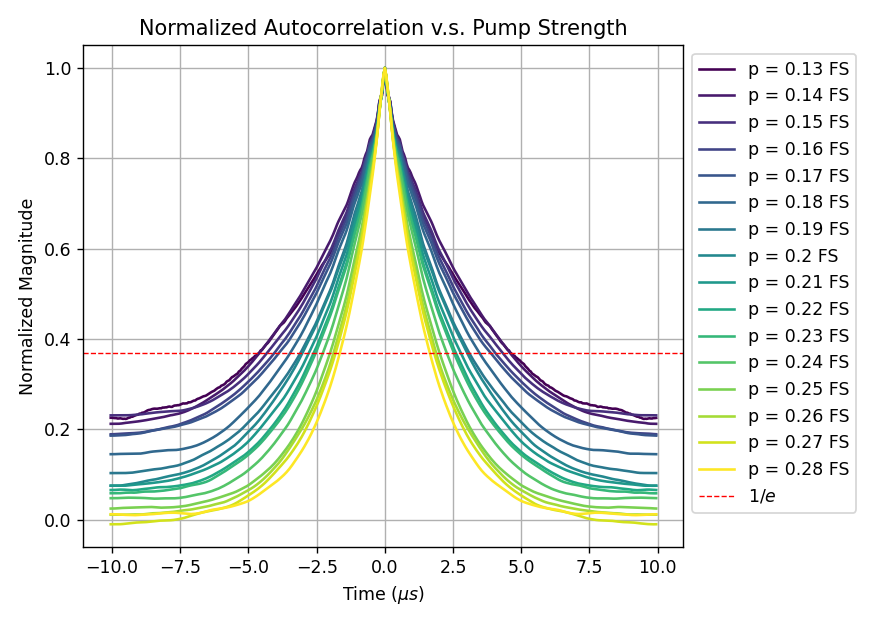

In [218]:
p_final = -1

cmap = cm.viridis
norm = mcolors.Normalize(vmin=pump_list[0], vmax=pump_list[p_final])


fig, ax = plt.subplots(
    nrows=1,
    figsize=(7, 5), 
    tight_layout=True,
    dpi=125
    )

for p_idx, p in enumerate(pump_list[:]):
    colors = cmap(norm(p))
    ax.plot(
        t_arr, 
        autocorr_list[p_idx]/np.max(autocorr_list[p_idx]),
        color=colors,
        label= f'p = {p} FS'
    )

ax.axhline(
    y=1/np.e,
    ls='--',
    lw=0.8,
    color='red',
    label='$1/e$'
    )

ax.grid()
ax.set_xlabel('Time ($\\mu s$)')
ax.set_ylabel('Normalized Magnitude')
ax.set_title('Normalized Autocorrelation v.s. Pump Strength')
ax.legend(
    bbox_to_anchor=(1,1)
)


# sm = cm.ScalarMappable(cmap=cmap, norm=norm)
# sm.set_array([])  # needed for older matplotlib behavior

# cbar = fig.colorbar(sm, ax=ax)
# cbar.set_label("Pump")
